# YOU CAN GET ALL MODEL_TRAINING FILE  AND  TEST FILE HERE "https://drive.google.com/drive/folders/1RlYLfgYQ-ny9RP7vn31vHjXHFRWXOqBz?usp=sharing"

# importing libraries

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
#import cv2
#from tensorflow.keras.preprocessing.image import load_img



## Loading model
### train model link: "https://drive.google.com/drive/folders/1RlYLfgYQ-ny9RP7vn31vHjXHFRWXOqBz?usp=sharing"
### USE: train_model.keras OR train_model.h5

In [ ]:
model = tf.keras.models.load_model('trained_model.keras')

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

## Visualizing Single Image of Test Set

In [ ]:
!pip install opencv-python

In [ ]:
import cv2

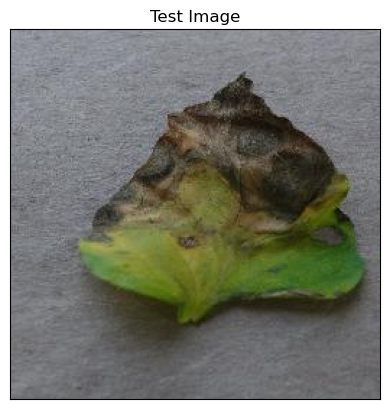

In [ ]:
image_path = "test/TomatoEarlyBlight2.JPG"   #give path of Image

#Reading Image
img = cv2.imread(image_path)

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert BGR image to RGB


#Displaying Image with BGR format
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [ ]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
#print(image)
input_arr = np.array([input_arr])  #Convert single image to batch
print(input_arr.shape)

(1, 128, 128, 3)


In [ ]:
prediction = model.predict(input_arr)
prediction

1/1 [==============================] - 0s 368ms/step


array([[1.6421222e-04, 6.2978156e-06, 1.4383470e-04, 7.1328832e-06,
        6.4665669e-06, 9.1065804e-06, 2.8249610e-06, 8.7176329e-03,
        1.3620261e-05, 1.5640253e-05, 3.4982193e-06, 7.6898723e-04,
        6.7592092e-04, 7.0331222e-04, 2.5098796e-05, 2.4542330e-06,
        5.3053034e-05, 2.7030080e-06, 1.2489109e-05, 1.8273331e-05,
        3.5758960e-04, 2.9481386e-03, 8.3923360e-06, 1.4566256e-05,
        1.1193650e-05, 3.7903254e-05, 2.1596119e-04, 1.6324022e-06,
        2.8975937e-03, 8.2267696e-01, 1.3330621e-01, 1.0972321e-03,
        2.3758303e-02, 6.7880646e-05, 5.2624237e-04, 1.4277376e-04,
        2.3627555e-04, 3.4258139e-04]], dtype=float32)

In [ ]:
prediction.shape

(1, 38)

In [ ]:
result_index = np.argmax(prediction)
result_index

29

In [ ]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

# Displaying Result

In [ ]:
model_prediction = class_name[result_index]

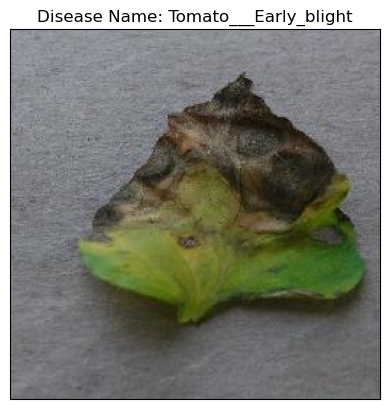

In [ ]:
model_prediction
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()